# Decoder-Only Transformer (GPT)

A compact, character-level GPT in PyTorch on TinyShakespeare.

## Goals

1. Build core GPT layers.
2. Verify training behavior with rigorous sanity checks.
3. Train with modern best practices (cosine LR, mixed precision, gradient accumulation).
4. Generate text with controllable sampling (temperature, top-k, top-p).
5. Visualize training dynamics and save experiment artifacts.

## Architecture

`tokens -> token+position embeddings -> Transformer blocks x N -> LayerNorm -> linear head`

Uses **pre-norm** blocks (`LayerNorm` before each sublayer).

In [14]:
from pathlib import Path
import json
import math
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

plt.style.use("seaborn-v0_8-darkgrid")

CONFIG = {
    "seed": 42,
    "block_size": 128,
    "batch_size": 32,
    "n_embd": 128,
    "n_heads": 4,
    "n_layers": 4,
    "dropout": 0.2,
    # Optimizer
    "learning_rate": 3e-4,
    "min_lr": 3e-5,
    "weight_decay": 1e-2,
    # LR schedule
    "warmup_iters": 200,
    # Training loop
    "max_iters": 2000,
    "eval_interval": 200,
    "eval_batches": 50,
    # Gradient accumulation (effective batch = batch_size * grad_accum_steps)
    "grad_accum_steps": 4,
    # Mixed precision
    "use_amp": True,
}

SEED = CONFIG["seed"]
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
print(f"Config: n_embd={CONFIG['n_embd']}, n_heads={CONFIG['n_heads']}, "
      f"n_layers={CONFIG['n_layers']}, block_size={CONFIG['block_size']}")
print(f"Effective batch size: {CONFIG['batch_size'] * CONFIG['grad_accum_steps']}")
print(f"Mixed precision: {CONFIG['use_amp']}")

Device: cuda
Config: n_embd=128, n_heads=4, n_layers=4, block_size=128
Effective batch size: 128
Mixed precision: True


## Load Artifacts

Load vocabulary and token tensors from `2. Preprocessing.ipynb` outputs for consistent splits.

In [15]:
# Resolve project root regardless of where the notebook kernel starts.
cwd = Path.cwd()
if (cwd / "data").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "data").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError(f"Cannot locate 'data' directory from cwd: {cwd}")

ARTIFACTS_DIR = PROJECT_ROOT / "data" / "artifacts"

# --- Load vocabulary ---
with open(ARTIFACTS_DIR / "char_vocab.json", "r", encoding="utf-8") as f:
    vocab_payload = json.load(f)

vocab_size = vocab_payload["vocab_size"]
chars = vocab_payload["chars"]
stoi = vocab_payload["stoi"]
itos = {int(k): v for k, v in vocab_payload["itos"].items()}

def encode(text: str):
    """Convert a string to a list of integer token ids."""
    return [stoi[ch] for ch in text]

def decode(indices):
    """Convert a list of integer token ids back to a string."""
    return "".join(itos[int(i)] for i in indices)

# --- Load pre-encoded tensors ---
train_ids = torch.load(ARTIFACTS_DIR / "train_ids.pt", weights_only=True)
val_ids = torch.load(ARTIFACTS_DIR / "val_ids.pt", weights_only=True)
test_ids = torch.load(ARTIFACTS_DIR / "test_ids.pt", weights_only=True)

print(f"Vocab size: {vocab_size}")
print(f"Train tokens: {len(train_ids):,} | Val tokens: {len(val_ids):,} | Test tokens: {len(test_ids):,}")

# --- Batch sampling function ---
block_size = CONFIG["block_size"]
batch_size = CONFIG["batch_size"]

def get_batch(split: str):
    """Sample a random batch of (x, y) pairs for next-token prediction."""
    data = {"train": train_ids, "val": val_ids, "test": test_ids}[split]
    ix = torch.randint(0, len(data) - block_size - 1, (batch_size,))
    x = torch.stack([data[i : i + block_size] for i in ix])
    y = torch.stack([data[i + 1 : i + block_size + 1] for i in ix])
    return x.to(device), y.to(device)

# Quick verification
x, y = get_batch("train")
print(f"\nBatch shapes — x: {tuple(x.shape)}, y: {tuple(y.shape)}")
print(f"Sample decode (first 60 chars): {decode(x[0][:60].tolist())}")

Vocab size: 65
Train tokens: 1,003,854 | Val tokens: 55,770 | Test tokens: 55,770

Batch shapes — x: (32, 128), y: (32, 128)
Sample decode (first 60 chars):  passage.

Second Watchman:
Ay, wherefore else guard we his 


## Model Architecture

We build a decoder-only GPT in four parts:

- `CausalSelfAttention`: masked multi-head attention (`scaled_dot_product_attention`)
- `FeedForward`: position-wise MLP (4x expansion + GELU)
- `TransformerBlock`: pre-norm residual attention + FFN
- `GPT`: embeddings -> blocks -> final norm -> vocab logits

Pattern used throughout: `x + sublayer(LayerNorm(x))`.

In [16]:
class CausalSelfAttention(nn.Module):
    """
    Multi-head causal self-attention.

    Uses torch.nn.functional.scaled_dot_product_attention which automatically
    dispatches to FlashAttention or memory-efficient attention kernels on
    supported hardware (e.g. H100), avoiding the need for explicit causal masks.
    """

    def __init__(self, n_embd: int, n_heads: int, block_size: int, dropout: float):
        super().__init__()
        assert n_embd % n_heads == 0, "n_embd must be divisible by n_heads"

        self.n_heads = n_heads
        self.head_dim = n_embd // n_heads
        self.dropout = dropout

        # Combined Q, K, V projection for efficiency
        self.qkv_proj = nn.Linear(n_embd, 3 * n_embd, bias=False)
        # Output projection
        self.out_proj = nn.Linear(n_embd, n_embd, bias=False)
        self.resid_dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, C = x.shape

        # Project to Q, K, V and split into heads: (B, T, C) -> 3x (B, n_heads, T, head_dim)
        qkv = self.qkv_proj(x)
        q, k, v = qkv.chunk(3, dim=-1)
        q = q.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)

        # Scaled dot-product attention with causal mask (FlashAttention path)
        attn_out = F.scaled_dot_product_attention(
            q, k, v,
            is_causal=True,
            dropout_p=self.dropout if self.training else 0.0,
        )

        # Merge heads back: (B, n_heads, T, head_dim) -> (B, T, C)
        attn_out = attn_out.transpose(1, 2).contiguous().view(B, T, C)
        return self.resid_dropout(self.out_proj(attn_out))

### Feed-Forward Network

A 2-layer MLP per token position: expand 4x, apply GELU, project back.

$$\text{FFN}(x)=\text{GELU}(xW_1+b_1)W_2+b_2$$

In [17]:
class FeedForward(nn.Module):
    """Position-wise feed-forward network with 4x hidden expansion and GELU."""

    def __init__(self, n_embd: int, dropout: float):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.GELU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

### Transformer Block

Each block uses pre-norm residual updates:

```
x = x + Attention(LayerNorm(x))
x = x + FFN(LayerNorm(x))
```

Residuals help gradient flow; LayerNorm improves stability.

In [18]:
class TransformerBlock(nn.Module):
    """Single Transformer block: pre-norm attention + pre-norm FFN with residuals."""

    def __init__(self, n_embd: int, n_heads: int, block_size: int, dropout: float):
        super().__init__()
        self.ln1 = nn.LayerNorm(n_embd)
        self.attn = CausalSelfAttention(n_embd, n_heads, block_size, dropout)
        self.ln2 = nn.LayerNorm(n_embd)
        self.ffn = FeedForward(n_embd, dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.attn(self.ln1(x))
        x = x + self.ffn(self.ln2(x))
        return x

### The Full GPT Model

Pipeline:
1. Token embeddings
2. Position embeddings
3. `N` Transformer blocks
4. Final LayerNorm
5. Linear LM head to logits

`generate()` supports controllable sampling:
- **temperature**: < 1.0 is more deterministic, > 1.0 is more random
- **top_k**: only sample from the top-k most likely tokens
- **top_p** (nucleus): only sample from the smallest set whose cumulative probability >= p
- **repetition_penalty**: penalize tokens that already appeared in the context

In [19]:
class GPT(nn.Module):
    """
    Decoder-only GPT language model.

    Combines token/position embeddings, a stack of Transformer blocks,
    a final layer norm, and a linear head projecting to vocabulary logits.
    """

    def __init__(self, vocab_size: int, n_embd: int, n_heads: int,
                 n_layers: int, block_size: int, dropout: float):
        super().__init__()
        self.block_size = block_size

        self.token_emb = nn.Embedding(vocab_size, n_embd)
        self.pos_emb = nn.Embedding(block_size, n_embd)
        self.drop = nn.Dropout(dropout)

        self.blocks = nn.Sequential(*[
            TransformerBlock(n_embd, n_heads, block_size, dropout)
            for _ in range(n_layers)
        ])

        self.ln_f = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size, bias=False)

        # Weight tying reduces parameters and improves generalization.
        self.token_emb.weight = self.lm_head.weight

        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx: torch.Tensor, targets: torch.Tensor = None):
        B, T = idx.shape
        assert T <= self.block_size, f"Sequence length {T} exceeds block_size {self.block_size}"

        tok_emb = self.token_emb(idx)
        pos_emb = self.pos_emb(torch.arange(T, device=idx.device))
        x = self.drop(tok_emb + pos_emb)

        x = self.blocks(x)
        x = self.ln_f(x)
        logits = self.lm_head(x)

        loss = None
        if targets is not None:
            loss = F.cross_entropy(
                logits.view(-1, logits.size(-1)),
                targets.view(-1),
            )

        return logits, loss

    @torch.no_grad()
    def generate(self, idx: torch.Tensor, max_new_tokens: int,
                 temperature: float = 1.0, top_k: int = 0, top_p: float = 1.0,
                 repetition_penalty: float = 1.0):
        """
        Autoregressive generation with temperature, top-k, top-p (nucleus),
        and repetition penalty.
        """
        self.eval()
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -self.block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :]  # (B, vocab_size)

            # Repetition penalty: reduce logits of tokens already generated
            if repetition_penalty != 1.0:
                for b in range(idx.size(0)):
                    prev_tokens = idx[b].unique()
                    logits[b, prev_tokens] /= repetition_penalty

            logits = logits / temperature

            # Top-k filtering
            if top_k > 0:
                top_k_val = min(top_k, logits.size(-1))
                kth_vals = torch.topk(logits, top_k_val, dim=-1).values[:, -1:]
                logits = logits.masked_fill(logits < kth_vals, float("-inf"))

            # Top-p (nucleus) filtering
            if top_p < 1.0:
                sorted_logits, sorted_idx = torch.sort(logits, descending=True, dim=-1)
                cum_probs = torch.cumsum(F.softmax(sorted_logits, dim=-1), dim=-1)
                remove_mask = cum_probs - F.softmax(sorted_logits, dim=-1) >= top_p
                sorted_logits[remove_mask] = float("-inf")
                logits = sorted_logits.scatter(1, sorted_idx, sorted_logits)

            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat([idx, idx_next], dim=1)
        return idx

### Model Instantiation

Instantiate the baseline model and inspect parameter count.

Baseline: `n_embd=128`, `n_heads=4`, `n_layers=4`.

In [20]:
model = GPT(
    vocab_size=vocab_size,
    n_embd=CONFIG["n_embd"],
    n_heads=CONFIG["n_heads"],
    n_layers=CONFIG["n_layers"],
    block_size=CONFIG["block_size"],
    dropout=CONFIG["dropout"],
).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"\nModel structure:\n{model}")

Total parameters: 816,000
Trainable parameters: 816,000

Model structure:
GPT(
  (token_emb): Embedding(65, 128)
  (pos_emb): Embedding(128, 128)
  (drop): Dropout(p=0.2, inplace=False)
  (blocks): Sequential(
    (0): TransformerBlock(
      (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
      (attn): CausalSelfAttention(
        (qkv_proj): Linear(in_features=128, out_features=384, bias=False)
        (out_proj): Linear(in_features=128, out_features=128, bias=False)
        (resid_dropout): Dropout(p=0.2, inplace=False)
      )
      (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
      (ffn): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=128, out_features=512, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=512, out_features=128, bias=True)
          (3): Dropout(p=0.2, inplace=False)
        )
      )
    )
    (1): TransformerBlock(
      (ln1): LayerNorm((128,), eps=1

## Sanity Checks

Before full training, run two diagnostic checks (both hard-asserted):

1. **Shape check**: forward pass on one batch produces `(B, T, vocab_size)` logits
2. **Overfit check**: memorize one fixed batch for 300 steps — loss must drop below 0.05

In [21]:
model.eval()
with torch.no_grad():
    xb, yb = get_batch("train")
    logits, loss = model(xb, yb)

expected_shape = (batch_size, block_size, vocab_size)
actual_shape = tuple(logits.shape)
expected_init_loss = math.log(vocab_size)

print(f"Expected logits shape: {expected_shape}")
print(f"Actual logits shape:   {actual_shape}")
print(f"Initial loss: {loss.item():.4f}  (expected ~ln({vocab_size}) = {expected_init_loss:.4f})")

assert actual_shape == expected_shape, f"Shape mismatch! Got {actual_shape}"
assert abs(loss.item() - expected_init_loss) < 0.5, (
    f"Initial loss {loss.item():.4f} too far from expected {expected_init_loss:.4f}"
)
print("\n✓ Shape + initial-loss test PASSED")

Expected logits shape: (32, 128, 65)
Actual logits shape:   (32, 128, 65)
Initial loss: 4.2055  (expected ~ln(65) = 4.1744)

✓ Shape + initial-loss test PASSED


### Overfitting Test

Train on one fixed batch for 300 steps with dropout disabled and no weight decay.

Expected: loss drops below 0.05. If not, gradient flow or architecture is broken.

Overfitting single batch for 300 iterations:
--------------------------------------------------
  Step   0 | Loss: 4.188018
  Step  50 | Loss: 2.529163
  Step 100 | Loss: 1.590386
  Step 150 | Loss: 0.386875
  Step 200 | Loss: 0.044978
  Step 250 | Loss: 0.023290
  Step 299 | Loss: 0.017343
--------------------------------------------------
✓ Overfit test PASSED — final loss 0.017343


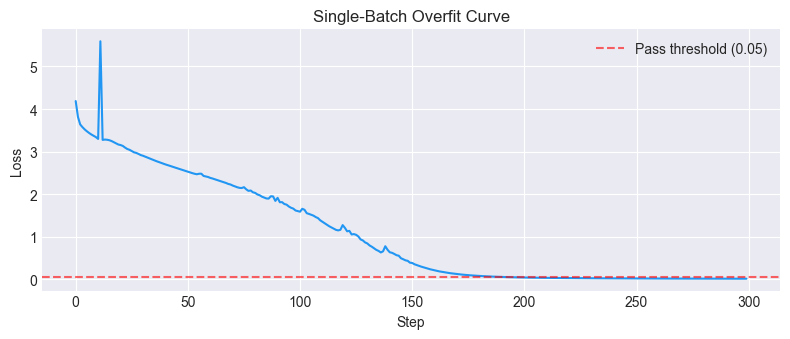

In [22]:
OVERFIT_STEPS = 300

overfit_model = GPT(
    vocab_size=vocab_size,
    n_embd=CONFIG["n_embd"],
    n_heads=CONFIG["n_heads"],
    n_layers=CONFIG["n_layers"],
    block_size=CONFIG["block_size"],
    dropout=0.0,
).to(device)

optimizer = torch.optim.AdamW(overfit_model.parameters(), lr=1e-3, weight_decay=0.0)

xb_fixed, yb_fixed = get_batch("train")

overfit_model.train()
overfit_losses = []
print(f"Overfitting single batch for {OVERFIT_STEPS} iterations:")
print("-" * 50)

for step in range(OVERFIT_STEPS):
    _, loss = overfit_model(xb_fixed, yb_fixed)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    overfit_losses.append(loss.item())

    if step % 50 == 0 or step == OVERFIT_STEPS - 1:
        print(f"  Step {step:3d} | Loss: {loss.item():.6f}")

final_loss = loss.item()
print("-" * 50)
assert final_loss < 0.05, f"Overfit test FAILED — loss {final_loss:.6f} should be < 0.05"
print(f"✓ Overfit test PASSED — final loss {final_loss:.6f}")

# --- Plot overfit curve ---
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(overfit_losses, linewidth=1.5, color="#2196F3")
ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.set_title("Single-Batch Overfit Curve")
ax.axhline(y=0.05, color="red", linestyle="--", alpha=0.6, label="Pass threshold (0.05)")
ax.legend()
fig.tight_layout()
plt.show()

del overfit_model, optimizer

### Baseline Training Run

Train on full data for 2,000 steps with modern training practices.

Setup:
- **AdamW** with weight decay (applied only to 2-D params, not biases/norms)
- **Cosine LR schedule** with linear warmup (200 steps)
- **Gradient clipping** (`max_norm=1.0`)
- **Gradient accumulation** (4 micro-steps → effective batch 128)
- **Mixed precision** (`torch.amp` with autocast + GradScaler)
- **Best checkpoint** saved by validation loss
- Logs: loss, perplexity, learning rate per eval step

In [23]:
def get_lr(step: int) -> float:
    """Cosine decay with linear warmup."""
    warmup = CONFIG["warmup_iters"]
    max_lr = CONFIG["learning_rate"]
    min_lr = CONFIG["min_lr"]
    max_iters = CONFIG["max_iters"]
    if step < warmup:
        return max_lr * (step + 1) / warmup
    if step >= max_iters:
        return min_lr
    ratio = (step - warmup) / (max_iters - warmup)
    return min_lr + 0.5 * (max_lr - min_lr) * (1 + math.cos(math.pi * ratio))


@torch.no_grad()
def estimate_loss(model, eval_batches: int = CONFIG["eval_batches"]):
    """Estimate train/val loss and perplexity over multiple random batches."""
    model.eval()
    results = {}
    for split in ("train", "val"):
        losses = []
        for _ in range(eval_batches):
            xb, yb = get_batch(split)
            with torch.amp.autocast(device_type=device, enabled=CONFIG["use_amp"]):
                _, loss = model(xb, yb)
            losses.append(loss.item())
        avg_loss = np.mean(losses)
        results[split] = {"loss": avg_loss, "ppl": math.exp(avg_loss)}
    model.train()
    return results


# ---------- Re-seed + fresh model ----------
torch.manual_seed(SEED)

model = GPT(
    vocab_size=vocab_size,
    n_embd=CONFIG["n_embd"],
    n_heads=CONFIG["n_heads"],
    n_layers=CONFIG["n_layers"],
    block_size=CONFIG["block_size"],
    dropout=CONFIG["dropout"],
).to(device)

# Separate weight-decay groups: decay on 2-D params only (not biases/layernorms)
decay_params = [p for p in model.parameters() if p.dim() >= 2]
no_decay_params = [p for p in model.parameters() if p.dim() < 2]
optimizer = torch.optim.AdamW([
    {"params": decay_params, "weight_decay": CONFIG["weight_decay"]},
    {"params": no_decay_params, "weight_decay": 0.0},
], lr=CONFIG["learning_rate"])

scaler = torch.amp.GradScaler(enabled=CONFIG["use_amp"])

max_iters = CONFIG["max_iters"]
eval_interval = CONFIG["eval_interval"]
grad_accum_steps = CONFIG["grad_accum_steps"]

# Logging history
history = {"step": [], "train_loss": [], "val_loss": [],
           "train_ppl": [], "val_ppl": [], "lr": []}

best_val_loss = float("inf")
best_state = None

print(f"Training for {max_iters} iterations (eval every {eval_interval})...")
print(f"Grad accumulation: {grad_accum_steps} micro-steps | AMP: {CONFIG['use_amp']}")
print("=" * 75)

model.train()
t0 = time.time()

for step in range(max_iters):
    # --- Cosine LR with warmup ---
    lr = get_lr(step)
    for pg in optimizer.param_groups:
        pg["lr"] = lr

    # --- Evaluation ---
    if step % eval_interval == 0 or step == max_iters - 1:
        metrics = estimate_loss(model)
        tl, vl = metrics["train"]["loss"], metrics["val"]["loss"]
        tp, vp = metrics["train"]["ppl"], metrics["val"]["ppl"]
        history["step"].append(step)
        history["train_loss"].append(tl)
        history["val_loss"].append(vl)
        history["train_ppl"].append(tp)
        history["val_ppl"].append(vp)
        history["lr"].append(lr)
        elapsed = time.time() - t0
        print(f"  Step {step:5d} | Train {tl:.4f} (ppl {tp:.1f}) | "
              f"Val {vl:.4f} (ppl {vp:.1f}) | LR {lr:.2e} | {elapsed:.1f}s")

        if vl < best_val_loss:
            best_val_loss = vl
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    # --- Gradient-accumulated forward/backward ---
    optimizer.zero_grad(set_to_none=True)
    for micro in range(grad_accum_steps):
        xb, yb = get_batch("train")
        with torch.amp.autocast(device_type=device, enabled=CONFIG["use_amp"]):
            _, loss = model(xb, yb)
            loss = loss / grad_accum_steps
        scaler.scale(loss).backward()

    scaler.unscale_(optimizer)
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    scaler.step(optimizer)
    scaler.update()

print("=" * 75)

# Restore best checkpoint
model.load_state_dict(best_state)
model.to(device)

final = estimate_loss(model)
print(f"\nTraining complete ({time.time() - t0:.1f}s).")
print(f"  Best val loss:   {best_val_loss:.4f} (ppl {math.exp(best_val_loss):.1f})")
print(f"  Final train loss: {final['train']['loss']:.4f} (ppl {final['train']['ppl']:.1f})")
print(f"  Final val loss:   {final['val']['loss']:.4f} (ppl {final['val']['ppl']:.1f})")

Training for 2000 iterations (eval every 200)...
Grad accumulation: 4 micro-steps | AMP: True
  Step     0 | Train 4.1895 (ppl 66.0) | Val 4.1911 (ppl 66.1) | LR 1.50e-06 | 0.8s
  Step   200 | Train 2.5748 (ppl 13.1) | Val 2.5676 (ppl 13.0) | LR 3.00e-04 | 18.1s
  Step   400 | Train 2.3810 (ppl 10.8) | Val 2.3881 (ppl 10.9) | LR 2.92e-04 | 35.1s
  Step   600 | Train 2.2406 (ppl 9.4) | Val 2.2543 (ppl 9.5) | LR 2.68e-04 | 51.8s
  Step   800 | Train 2.1154 (ppl 8.3) | Val 2.1399 (ppl 8.5) | LR 2.32e-04 | 68.7s
  Step  1000 | Train 2.0060 (ppl 7.4) | Val 2.0587 (ppl 7.8) | LR 1.88e-04 | 85.5s
  Step  1200 | Train 1.9376 (ppl 6.9) | Val 2.0012 (ppl 7.4) | LR 1.42e-04 | 102.2s
  Step  1400 | Train 1.9044 (ppl 6.7) | Val 1.9670 (ppl 7.1) | LR 9.75e-05 | 118.8s
  Step  1600 | Train 1.8668 (ppl 6.5) | Val 1.9509 (ppl 7.0) | LR 6.16e-05 | 135.6s
  Step  1800 | Train 1.8429 (ppl 6.3) | Val 1.9327 (ppl 6.9) | LR 3.81e-05 | 152.8s
  Step  1999 | Train 1.8332 (ppl 6.3) | Val 1.9336 (ppl 6.9) | LR 3

### Training Curves

Loss and perplexity over training, with the learning-rate schedule overlaid.

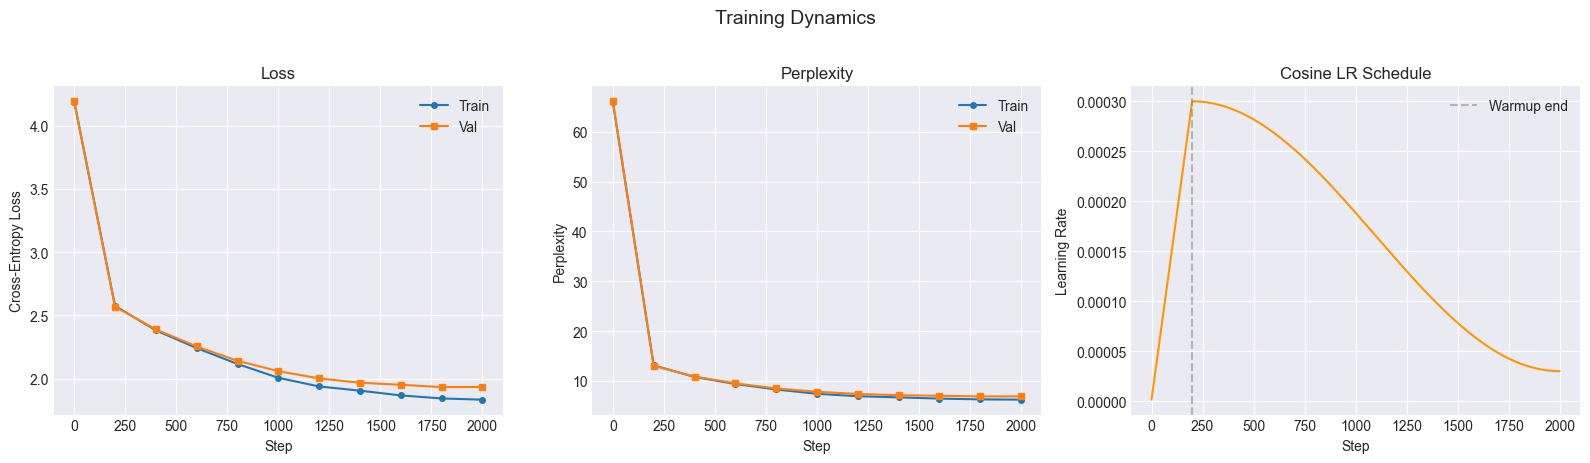

In [24]:
steps = history["step"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# --- Loss ---
ax = axes[0]
ax.plot(steps, history["train_loss"], "o-", label="Train", linewidth=1.5, markersize=4)
ax.plot(steps, history["val_loss"], "s-", label="Val", linewidth=1.5, markersize=4)
ax.set_xlabel("Step")
ax.set_ylabel("Cross-Entropy Loss")
ax.set_title("Loss")
ax.legend()

# --- Perplexity ---
ax = axes[1]
ax.plot(steps, history["train_ppl"], "o-", label="Train", linewidth=1.5, markersize=4)
ax.plot(steps, history["val_ppl"], "s-", label="Val", linewidth=1.5, markersize=4)
ax.set_xlabel("Step")
ax.set_ylabel("Perplexity")
ax.set_title("Perplexity")
ax.legend()

# --- Learning Rate Schedule ---
ax = axes[2]
lr_curve = [get_lr(s) for s in range(max_iters)]
ax.plot(lr_curve, linewidth=1.5, color="#FF9800")
ax.axvline(CONFIG["warmup_iters"], color="gray", linestyle="--", alpha=0.5, label="Warmup end")
ax.set_xlabel("Step")
ax.set_ylabel("Learning Rate")
ax.set_title("Cosine LR Schedule")
ax.legend()

fig.suptitle("Training Dynamics", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

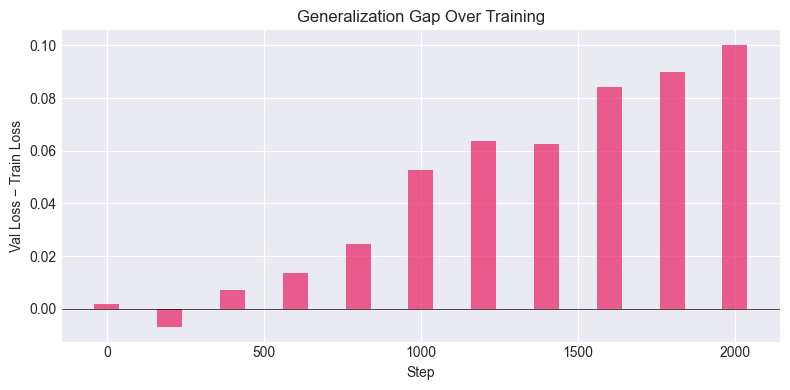

In [25]:
fig, ax = plt.subplots(figsize=(8, 4))
gap = [v - t for t, v in zip(history["train_loss"], history["val_loss"])]
ax.bar(steps, gap, width=max(steps) * 0.04, color="#E91E63", alpha=0.7)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_xlabel("Step")
ax.set_ylabel("Val Loss − Train Loss")
ax.set_title("Generalization Gap Over Training")
fig.tight_layout()
plt.show()

## Text Generation (Best Checkpoint)

Generate from the best-validation-loss checkpoint using multiple sampling strategies:

| Strategy | Settings | Effect |
|---|---|---|
| Greedy-ish | `temp=0.5` | Conservative, repetitive |
| Balanced | `temp=0.8, top_k=40` | Good coherence + variety |
| Nucleus | `temp=1.0, top_p=0.9` | Creative, diverse |
| Penalized | `temp=0.9, top_k=50, rep_pen=1.2` | Reduces repetition loops |

In [26]:
prompt = "ROMEO:"
context = torch.tensor([encode(prompt)], dtype=torch.long, device=device)

sampling_configs = [
    {"label": "Greedy-ish (temp=0.5)",
     "temperature": 0.5},
    {"label": "Balanced (temp=0.8, top_k=40)",
     "temperature": 0.8, "top_k": 40},
    {"label": "Nucleus (temp=1.0, top_p=0.9)",
     "temperature": 1.0, "top_p": 0.9},
    {"label": "Penalized (temp=0.9, top_k=50, rep_pen=1.2)",
     "temperature": 0.9, "top_k": 50, "repetition_penalty": 1.2},
]

generated_samples = {}

for cfg in sampling_configs:
    label = cfg.pop("label")
    print(f"\n{'=' * 60}")
    print(f"  {label}")
    print(f"{'=' * 60}\n")
    ids = model.generate(context.clone(), max_new_tokens=500, **cfg)
    text = decode(ids[0].tolist())
    generated_samples[label] = text
    print(text)
    cfg["label"] = label  # restore for metadata


  Greedy-ish (temp=0.5)

ROMEO:
And you fainst the some the have me and me.

RICARD:
I where the a home that she sire all my be hearth have
I I he have you such in my lordser and my like,
And the shall ward so be that of the the a the ar be the do have hearther
Whou was the have the me, for word this fand I herers
And by sthe me the for the and heir the from and of have bearther
and Bearth un in a this the be he greaths such of the sone,
The have of rest the the make the well and in the for to the she kind
And the hous me the

  Balanced (temp=0.8, top_k=40)

ROMEO:
Bord, the have sword ming.

KING G RIK:
He, is much this this will:
Sherer moret deain this sheal so night frier ase
To your his have and this brootes but me.

ANGGAUCET:
I the ark beg, he aw heer gave o my sir, the dearth;
Thing the oof the purt to hears, you my and fighter.

ESTORO:
Xurstalk, yell bes freaving of huse crown I prow!
Now Lard, that the wands not beh die my sheall.

COMENIZE:
And it is the lad, let prage th

## Save Experiment Artifacts

Persist the best checkpoint, full config, training history, and sample outputs for reproducibility.

In [27]:
CHECKPOINT_DIR = ARTIFACTS_DIR / "model"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# Save best model weights
torch.save(best_state, CHECKPOINT_DIR / "gpt_best.pt")

# Save experiment metadata
experiment = {
    "config": CONFIG,
    "vocab_size": vocab_size,
    "total_params": sum(p.numel() for p in model.parameters()),
    "best_val_loss": best_val_loss,
    "best_val_ppl": math.exp(best_val_loss),
    "final_train_loss": final["train"]["loss"],
    "final_val_loss": final["val"]["loss"],
    "history": history,
    "generated_samples": generated_samples,
}

with open(CHECKPOINT_DIR / "experiment.json", "w", encoding="utf-8") as f:
    json.dump(experiment, f, indent=2)

print(f"Saved to {CHECKPOINT_DIR}:")
print(f"  gpt_best.pt        ({CHECKPOINT_DIR / 'gpt_best.pt'})")
print(f"  experiment.json     ({CHECKPOINT_DIR / 'experiment.json'})")

Saved to c:\Users\utkar\OneDrive\Desktop\Northwestern University\Studies\NLP\Gen AI\genre-story-generator\data\artifacts\model:
  gpt_best.pt        (c:\Users\utkar\OneDrive\Desktop\Northwestern University\Studies\NLP\Gen AI\genre-story-generator\data\artifacts\model\gpt_best.pt)
  experiment.json     (c:\Users\utkar\OneDrive\Desktop\Northwestern University\Studies\NLP\Gen AI\genre-story-generator\data\artifacts\model\experiment.json)


## Summary

**Built:**
- Decoder-only character GPT (816K params) with FlashAttention + pre-norm residual blocks
- Controllable generation: temperature, top-k, nucleus (top-p), repetition penalty

**Training practices:**
- Cosine LR with linear warmup
- Mixed precision (AMP)
- Gradient accumulation (effective batch 128)
- Proper weight-decay grouping (2-D params only)
- Best-checkpoint saving by validation loss

**Validated:**
- Shape test (asserted)
- Single-batch overfit to near-zero loss (asserted < 0.05)
- Decreasing train + val loss over 2,000 steps

**Visualized:**
- Loss and perplexity curves (train vs. val)
- Learning-rate schedule
- Generalization gap

**Next steps:**
- Hyperparameter sweeps (depth, width, heads, dropout)
- Tokenizer upgrade (BPE) for better output quality
- Evaluate on held-out test set with perplexity